In [8]:
!pip install rasterio

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
base_path = "/content/drive/MyDrive/EuroSATallBands/EuroSATallBands"

In [7]:
# for verify
import os

print(os.listdir(base_path))

['AnnualCrop ', 'Forest ', 'River ', 'Residential ', 'Industrial ', 'SeaLake ', 'Highway ', 'Pasture ', 'HerbaceousVegetation ', 'PermanentCrop ']


In [9]:
# Load Multispectral .tif Images
import rasterio
import numpy as np

def load_tif(path):
    with rasterio.open(path) as src:
        img = src.read()  # (bands, H, W)

    # Select bands: B2, B3, B4, B8
    img = np.stack([
        img[1],  # Blue
        img[2],  # Green
        img[3],  # Red
        img[7]   # NIR
    ], axis=-1)

    return img

In [12]:
# pick one image manually
import os

sample_folder = os.path.join(base_path, "Forest ") # Corrected: Added a trailing space
sample_file = os.listdir(sample_folder)[0]

sample_path = os.path.join(sample_folder, sample_file)

img = load_tif(sample_path)

print(img.shape)

(64, 64, 4)


In [13]:
# Add NDVI
def add_ndvi(img):
    red = img[:, :, 2]
    nir = img[:, :, 3]

    ndvi = (nir - red) / (nir + red + 1e-6)

    return np.dstack((img, ndvi))

In [14]:
# test it
img_ndvi = add_ndvi(img)
print(img_ndvi.shape)

(64, 64, 5)


In [17]:
# class Mapping
mapping = {
    "Residential ": 0,
    "Industrial ": 0,

    "River ": 1,
    "SeaLake ": 1,

    "Forest ": 2,
    "AnnualCrop ": 2,
    "PermanentCrop ": 2,
    "Pasture ": 2,
    "HerbaceousVegetation ": 2,

    "Highway ": 3
}

In [18]:
# Load FULL DATASET
import os

X, y = [], []

LIMIT = 200

for cls in mapping.keys():
    folder = os.path.join(base_path, cls)
    files = os.listdir(folder)[:LIMIT]

    for file in files:
        if file.endswith(".tif"):
            path = os.path.join(folder, file)

            img = load_tif(path)
            img = img / 10000.0
            img = add_ndvi(img)

            X.append(img)
            y.append(mapping[cls])

X = np.array(X)
y = np.array(y)

print(X.shape, y.shape)

(2000, 64, 64, 5) (2000,)


In [19]:
# Split Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(1600, 64, 64, 5) (400, 64, 64, 5)


In [20]:
# CNN Model
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(64,64,5)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
# Train Model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 19s 305ms/step - accuracy: 0.7738 - loss: 0.6457 - val_accuracy: 0.8350 - val_loss: 0.4716
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 303ms/step - accuracy: 0.8788 - loss: 0.3189 - val_accuracy: 0.8975 - val_loss: 0.3086
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 292ms/step - accuracy: 0.9094 - loss: 0.2627 - val_accuracy: 0.8875 - val_loss: 0.3100
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 14s 289ms/step - accuracy: 0.9231 - loss: 0.2384 - val_accuracy: 0.9175 - val_loss: 0.2327
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 289ms/step - accuracy: 0.9206 - loss: 0.2379 - val_accuracy: 0.9125 - val_loss: 0.2459
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 300ms/step - accuracy: 0.9331 - loss: 0.1989 - val_accuracy: 0.9225 - val_loss: 0.2455
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 295ms/step - accuracy: 0.9312 - loss: 0.2132 - val_accuracy: 0.9075 - val_loss: 0.3024
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 292ms/step - accuracy: 0.9444 - loss: 0.1590 - val_accu

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step


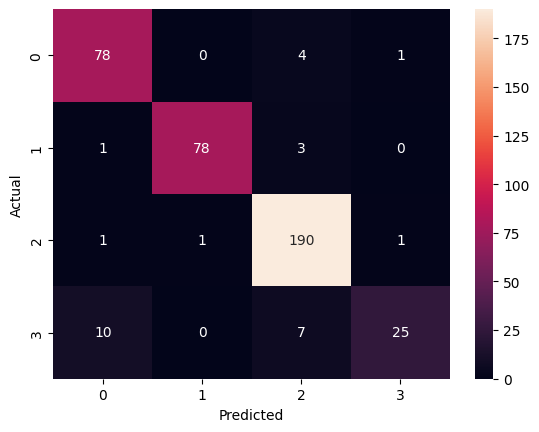

In [22]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90        83
           1       0.99      0.95      0.97        82
           2       0.93      0.98      0.96       193
           3       0.93      0.60      0.72        42

    accuracy                           0.93       400
   macro avg       0.93      0.87      0.89       400
weighted avg       0.93      0.93      0.92       400



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step


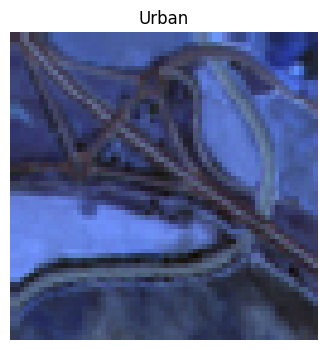

In [34]:
# Visual Prediction
import matplotlib.pyplot as plt
import numpy as np

# Define class names (IMPORTANT)
classes = ["Urban", "Water", "Vegetation", "Barren"]

def show_prediction(index):
    img = X_test[index]

    pred = model.predict(img[np.newaxis,...])
    label = classes[np.argmax(pred)]

    rgb = img[:, :, :3]

    # Normalize safely
    rgb = rgb - np.min(rgb)
    rgb = rgb / (np.max(rgb) + 1e-6)

    plt.figure(figsize=(4,4))   # ensures display
    plt.imshow(rgb)
    plt.title(label)
    plt.axis('off')
    plt.show()

# CALL FUNCTION (THIS IS REQUIRED)
show_prediction(0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


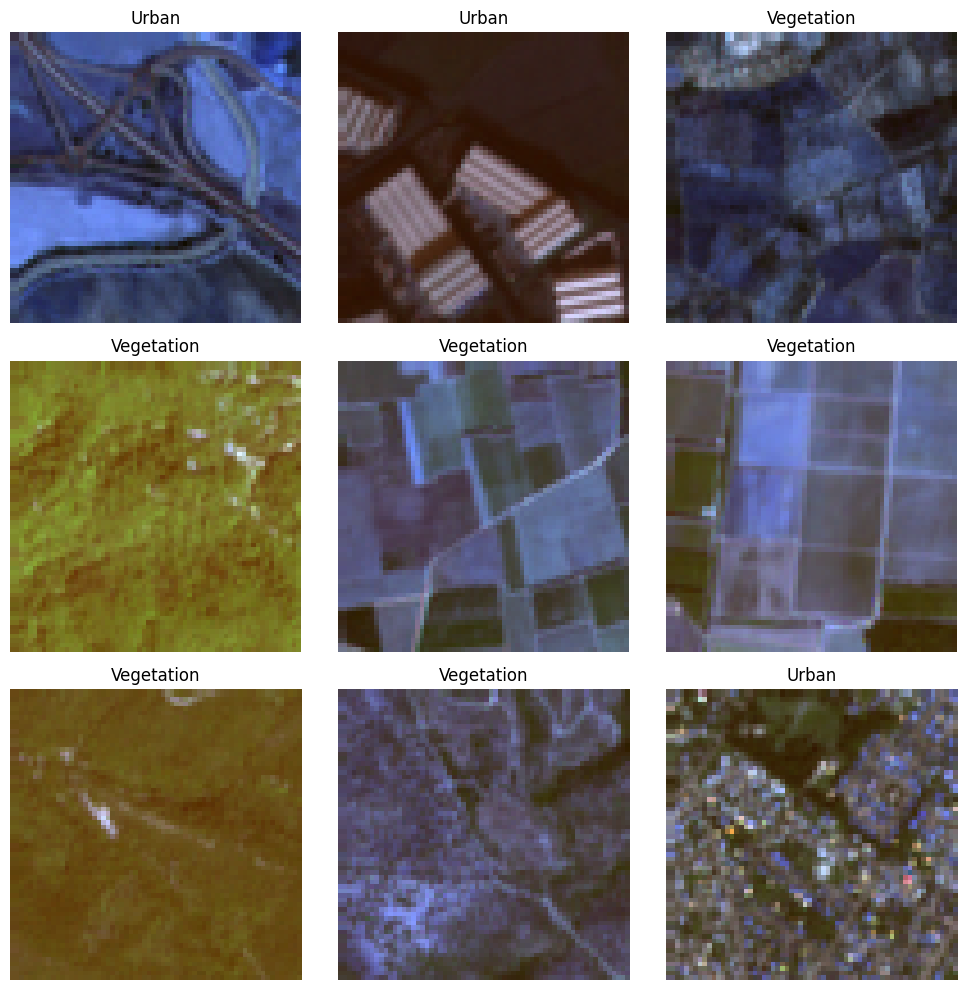

In [35]:
#Show Multiple Predictions
def show_multiple_predictions(num=9):
    plt.figure(figsize=(10,10))

    for i in range(num):
        img = X_test[i]

        pred = model.predict(img[np.newaxis,...])
        label = classes[np.argmax(pred)]

        rgb = img[:, :, :3]
        rgb = rgb - np.min(rgb)
        rgb = rgb / (np.max(rgb) + 1e-6)

        plt.subplot(3,3,i+1)
        plt.imshow(rgb)
        plt.title(label)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_multiple_predictions()

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step


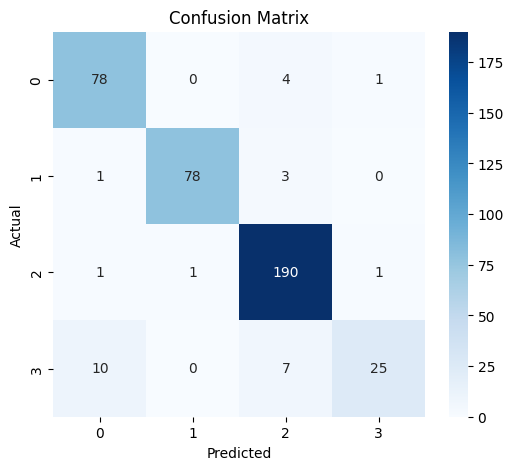

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = model.predict(X_test)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90        83
           1       0.99      0.95      0.97        82
           2       0.93      0.98      0.96       193
           3       0.93      0.60      0.72        42

    accuracy                           0.93       400
   macro avg       0.93      0.87      0.89       400
weighted avg       0.93      0.93      0.92       400



In [39]:
# model save
model.save("lulc_model.h5")

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.94      0.90        83
           1       0.99      0.95      0.97        82
           2       0.93      0.98      0.96       193
           3       0.93      0.60      0.72        42

    accuracy                           0.93       400
   macro avg       0.93      0.87      0.89       400
weighted avg       0.93      0.93      0.92       400

